In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### data

In [2]:
# report summary of the given files
def get_data_from_files(nseq_list, nseq_list_sub, *enrichment_files):
    df = pd.DataFrame([])
    for f in enrichment_files:
        df_i = pd.read_csv(f, sep="\t", index_col=0)
        df = pd.concat([df, df_i])
    
    df.columns = df.columns.astype(int)
    df = df.reindex(sorted(df.columns), axis=1)

    return([np.array(nseq_list), df.mean().values, np.array(nseq_list_sub), df.mean()[nseq_list_sub].values, df.sem()[nseq_list_sub].values])

In [3]:
def get_data_sample(data_type):
    full = pd.DataFrame([])
    sub = pd.DataFrame([])

    data = get_data_from_files(nseq_list, nseq_list_sub, "/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/%s/enrichment/RankColdness_100.txt" % data_type)
    full_df = pd.DataFrame([data[0], data[1]]).transpose()
    full_df["sample"] = data_type.replace("human", "")
    full_df["rank"] = "C-score"
    sub_df = pd.DataFrame([data[2], data[3], data[4]]).transpose()
    sub_df["sample"] = data_type.replace("human", "")
    sub_df["rank"] = "C-score"
    full = pd.concat([full, full_df])
    sub = pd.concat([sub, sub_df])

    data = get_data_from_files(nseq_list, nseq_list_sub, "/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/%s/enrichment/RankSPP_100.txt" % data_type)
    full_df = pd.DataFrame([data[0], data[1]]).transpose()
    full_df["sample"] = data_type.replace("human", "")
    full_df["rank"] = "SPP"
    sub_df = pd.DataFrame([data[2], data[3], data[4]]).transpose()
    sub_df["sample"] = data_type.replace("human", "")
    sub_df["rank"] = "SPP"
    full = pd.concat([full, full_df])
    sub = pd.concat([sub, sub_df])

    data = get_data_from_files(nseq_list, nseq_list_sub, "/home/jg2447/slayman/motif_inference/result/EnrichmentGenomeShuffle/%s/enrichment/RankColdness_100.txt" % data_type)
    full_df = pd.DataFrame([data[0], data[1]]).transpose()
    full_df["sample"] = data_type.replace("human", "")
    full_df["rank"] = "C-score Shuffled"
    sub_df = pd.DataFrame([data[2], data[3], data[4]]).transpose()
    sub_df["sample"] = data_type.replace("human", "")
    sub_df["rank"] = "C-score Shuffled"
    full = pd.concat([full, full_df])
    sub = pd.concat([sub, sub_df])

    data = get_data_from_files(nseq_list, nseq_list_sub, "/home/jg2447/slayman/motif_inference/result/EnrichmentGenomeShuffle/%s/enrichment/RankSPP_100.txt" % data_type)
    full_df = pd.DataFrame([data[0], data[1]]).transpose()
    full_df["sample"] = data_type.replace("human", "")
    full_df["rank"] = "SPP Shuffled"
    sub_df = pd.DataFrame([data[2], data[3], data[4]]).transpose()
    sub_df["sample"] = data_type.replace("human", "")
    sub_df["rank"] = "SPP Shuffled"
    full = pd.concat([full, full_df])
    sub = pd.concat([sub, sub_df])

    return((full, sub))

In [4]:
# fix variables
nseq_list_sub = [50]+list(range(250, 3250, 250))
nseq_list = list(range(50, 3010, 10))
alpha_list = np.round(np.append(np.arange(0.1,1.0,0.1), np.arange(1.0,11.0,1.0)), decimals=2)

color = [
    (0.0,0.75,1.0,0.6),
    (0.8,0.2 ,0.4,0.4),
    (0.0,0.75,1.0,0.6),
    (0.8,0.2 ,0.4,0.4)]
color = ["#c2d2ed", "#ed6a6d", "#c2d2ed", "#ed6a6d"]

In [5]:
full1, sub1 = get_data_sample("fly")
full2, sub2 = get_data_sample("worm")
full3, sub3 = get_data_sample("humanGM12878")
full4, sub4 = get_data_sample("humanK562")

full = pd.concat([full1, full2, full3, full4])
sub = pd.concat([sub1, sub2, sub3, sub4])

full.columns = ["top", "enrichment", "sample", "rank"]
sub.columns = ["top", "enrichment", "err", "sample", "rank"]

In [6]:
# jit for plot
sub.loc[sub["rank"] == "C-score", "top"] += 10
sub.loc[sub["rank"] == "C-score Shuffled", "top"] += 10

### plot

In [7]:
# plot a single line with error bar
def enrichment_line(ax, full, sub, color, sample):
    ax.plot("top", "enrichment", "-", data=full.query("sample == '%s' and rank == 'C-score'" % sample), color=color[0], lw=0.75)
    ax.plot("top", "enrichment", "-", data=full.query("sample == '%s' and rank == 'SPP'" % sample), color=color[1], lw=0.75)
    ax.plot("top", "enrichment", "--", data=full.query("sample == '%s' and rank == 'C-score Shuffled'" % sample), color=color[2], lw=0.75)
    ax.plot("top", "enrichment", "--", data=full.query("sample == '%s' and rank == 'SPP Shuffled'" % sample), color=color[3], lw=0.75)
    ax.xaxis.set_ticks([0, 1000, 2000, 3000])
    ax.tick_params(labelsize=6, pad=1, length=2.5, width=0.5)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(0.5)
        
    for i,r in enumerate(["C-score", "SPP", "C-score Shuffled", "SPP Shuffled"]):
        
        #### ribbon
#         y1 = sub.query("sample == '%s' and rank == '%s'" % (sample,r))["enrichment"].values + sub.query("sample == '%s' and rank == '%s'" % (sample,r))["err"].values
#         y2 = sub.query("sample == '%s' and rank == '%s'" % (sample,r))["enrichment"].values - sub.query("sample == '%s' and rank == '%s'" % (sample,r))["err"].values
#         ax.fill_between(
#             x = sub.query("sample == '%s' and rank == '%s'" % (sample,r))["top"],
#             y1 = y1,
#             y2 = y2,
#             color=color[i])
        
        #### error bar
        (_, caps, _) = ax.errorbar(
            x = sub.query("sample == '%s' and rank == '%s'" % (sample,r))["top"], 
            y = sub.query("sample == '%s' and rank == '%s'" % (sample,r))["enrichment"], 
            yerr = sub.query("sample == '%s' and rank == '%s'" % (sample,r))["err"], 
            fmt="o", ms=0.75, elinewidth=0.75, capsize=1, color=color[i])
        for cap in caps:
            cap.set_markeredgewidth(0)

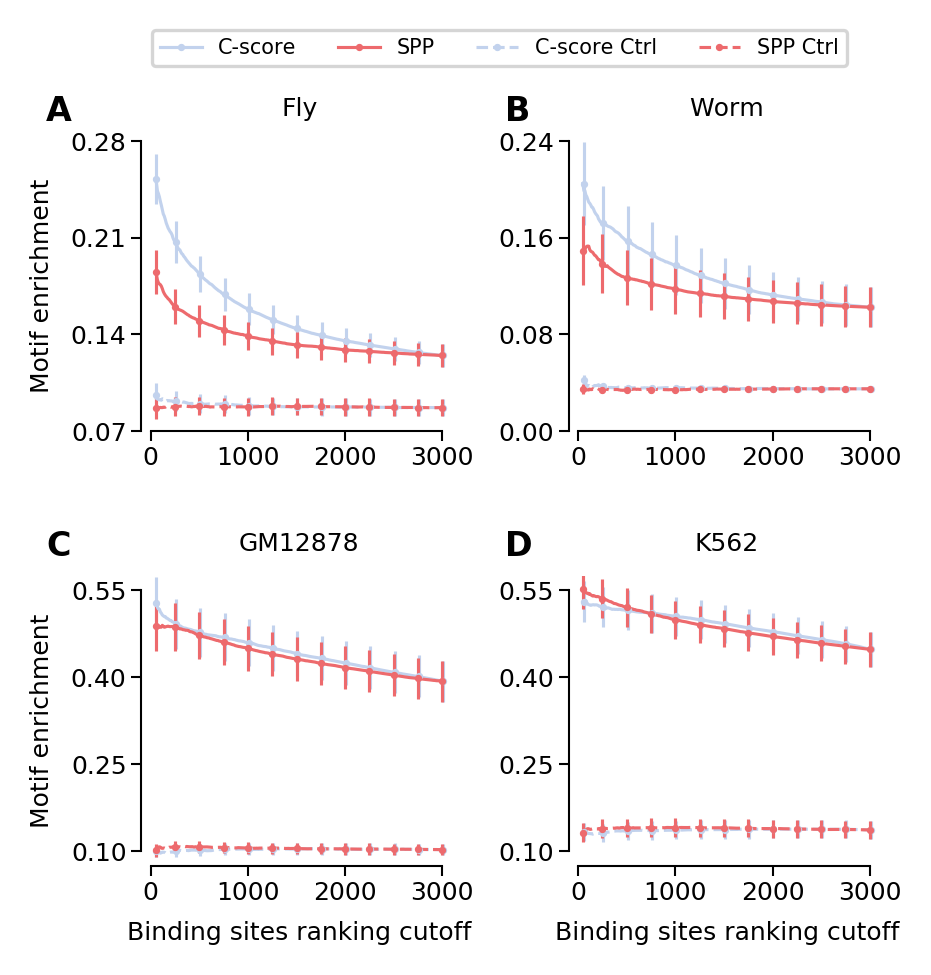

In [8]:
# plot
sns.set_context("paper")

fig, axs = plt.subplots(
    nrows=2, ncols=2, 
    sharex=False, sharey=False,
    gridspec_kw={'hspace': 0.5, 'wspace': 0.35, "height_ratios":[1, 1]},
    figsize=(3.2,3.2), dpi=300)

#### A
ax = axs[0,0]
enrichment_line(ax, full, sub, color, sample="fly")
ax.yaxis.set_ticks([0.07, 0.14, 0.21, 0.28])
ax.set_ylim([0.07,0.28])
ax.set_ylabel("Motif enrichment", fontsize=6)
ax.set_title("Fly", fontsize=6)
ax.text(-0.3, 1.07, "A", transform=ax.transAxes, size=8, weight='bold')

#### B
ax = axs[0,1]
enrichment_line(ax, full, sub, color, sample="worm")
ax.yaxis.set_ticks([0,0.08,0.16,0.24])
ax.set_ylim([0,0.24])
ax.set_title("Worm", fontsize=6)
ax.text(-0.2, 1.07, "B", transform=ax.transAxes, size=8, weight='bold')

#### C
ax = axs[1,0]
enrichment_line(ax, full, sub, color, sample="GM12878")
ax.yaxis.set_ticks([0.1, 0.25, 0.4, 0.55])
ax.tick_params(labelsize=6)
ax.set_ylim([0.075,0.575])
ax.set_ylabel("Motif enrichment", fontsize=6)
ax.set_xlabel("Binding sites ranking cutoff", fontsize=6)
ax.set_title("GM12878", fontsize=6)
ax.text(-0.3, 1.07, "C", transform=ax.transAxes, size=8, weight='bold')

#### D
ax = axs[1,1]
enrichment_line(ax, full, sub, color, sample="K562")
ax.yaxis.set_ticks([0.1, 0.25, 0.4, 0.55])
ax.tick_params(labelsize=6)
ax.set_ylim([0.075,0.575])
ax.set_xlabel("Binding sites ranking cutoff", fontsize=6)
ax.set_title("K562", fontsize=6)
ax.text(-0.2, 1.07, "D", transform=ax.transAxes, size=8, weight='bold')

#### legend
ax_cbar = axs[0,0]
ax_cbar.legend(
    handles=[
        (ax.lines[0], ax.lines[4]),
        (ax.lines[1], ax.lines[7]),
        (ax.lines[2], ax.lines[10]),
        (ax.lines[3], ax.lines[13])],
    labels=["C-score","SPP","C-score Ctrl","SPP Ctrl"],
    loc="upper left", fontsize=5, ncol=4, handlelength=2, bbox_to_anchor=(0,1.42))

sns.despine(trim=True)
plt.savefig("./fig2.pdf", dpi='figure', bbox_inches="tight")